<a href="https://colab.research.google.com/github/Archana330/Archana-Machine-Learning/blob/main/High-Risk%20pregnancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automated Clinical Decision Support: Risk Stratification of Maternal Health Outcomes Using Physiological IoT Dat**

# **Section 1: Importing Files and Dataset**

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
# Ensure Book2.xlsx is in your working directory
file_path = 'Book2.xlxl.xlsx'
df = pd.read_excel(file_path, header=1) # Using header=1 because row 0 is a title

# **Section 2: Clening the dataset**

In [28]:
# Rename columns for easier access
new_columns = [
    'Name', 'Age', 'Gravida', 'Tetanus_Vaccine', 'Gestational_Age',
    'Weight', 'Height', 'Blood_Pressure', 'Anemia', 'Jaundice',
    'Fetal_Position', 'Fetal_Movement', 'Fetal_Heart_Rate',
    'Urine_Albumin', 'Urine_Sugar', 'VDRL', 'HBsAG', 'Risk_Level'
]
df.columns = new_columns

# 1. Clean Numeric Columns
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Gestational_Age'] = df['Gestational_Age'].str.replace(' week', '').astype(float)
df['Weight'] = df['Weight'].str.replace(' kg', '').astype(float)
df['Fetal_Heart_Rate'] = df['Fetal_Heart_Rate'].str.replace('m', '').astype(float)

# 2. Split Blood Pressure into Systolic and Diastolic
df[['SystolicBP', 'DiastolicBP']] = df['Blood_Pressure'].str.split('/', expand=True).astype(float)

# 3. Standardize Target Variable
df['Risk_Level'] = df['Risk_Level'].map({'Yes': 'High Risk', 'No': 'Low Risk'})

# **Section 3: Exploraatory Data Analysis**

## **Dataset Inspection**

In [29]:
df.head()

,Name,Age,Gravida,Tetanus_Vaccine,Gestational_Age,Weight,Height,Blood_Pressure,Anemia,Jaundice,Fetal_Position,Fetal_Movement,Fetal_Heart_Rate,Urine_Albumin,Urine_Sugar,VDRL,HBsAG,Risk_Level,SystolicBP,DiastolicBP
0,Rituporna,18,1st,1st,38.0,50.0,5.3'',100/60,NaN,NaN,Normal,Normal,140.0,NaN,Yes,Negative,Negative,High Risk,100.0,60.0
1,Moina,25,2nd,2nd,38.0,60.0,5.2'',100/70,NaN,NaN,Normal,Normal,130.0,NaN,Yes,Positive,Negative,Low Risk,100.0,70.0
2,Rabeya,20,1st,1st,30.0,55.0,5.0'',100/60,NaN,NaN,Normal,Normal,120.0,NaN,Yes,Negative,Negative,High Risk,100.0,60.0
3,Shorna,22,1st,3rd,35.0,51.0,5.4'',110/65,NaN,NaN,Normal,Normal,130.0,NaN,Yes,Positive,Negative,High Risk,110.0,65.0
4,Tania Akter,20,1st,2nd,30.0,53.0,5.2'',100/55,NaN,NaN,Normal,Normal,125.0,NaN,Yes,Negative,Negative,Low Risk,100.0,55.0


## **Descriptive Statistical Analysis**

In [30]:
df.describe()

,Age,Gestational_Age,Weight,Fetal_Heart_Rate,SystolicBP,DiastolicBP
count,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000
mean,22.962926,28.938878,56.114228,132.279559,102.825651,64.574148
std,3.568168,4.969241,5.308816,8.889661,9.343101,7.914032
min,18.000000,20.000000,45.000000,120.000000,80.000000,55.000000
25%,20.000000,25.000000,52.000000,125.000000,100.000000,60.000000
50%,22.000000,30.000000,56.000000,130.000000,100.000000,60.000000
75%,25.000000,32.000000,61.000000,140.000000,110.000000,70.000000
max,32.000000,38.000000,65.000000,150.000000,120.000000,80.000000


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              998 non-null    object 
 1   Age               998 non-null    int64  
 2   Gravida           998 non-null    object 
 3   Tetanus_Vaccine   998 non-null    object 
 4   Gestational_Age   998 non-null    float64
 5   Weight            998 non-null    float64
 6   Height            998 non-null    object 
 7   Blood_Pressure    998 non-null    object 
 8   Anemia            123 non-null    object 
 9   Jaundice          12 non-null     object 
 10  Fetal_Position    998 non-null    object 
 11  Fetal_Movement    998 non-null    object 
 12  Fetal_Heart_Rate  998 non-null    float64
 13  Urine_Albumin     134 non-null    object 
 14  Urine_Sugar       998 non-null    object 
 15  VDRL              998 non-null    object 
 16  HBsAG             998 non-null    object 
 1

## **Check and Fill Missing Values**

In [32]:
# 1. Identify columns with missing values
missing_info = df.isnull().sum()
cols_to_fix = missing_info[missing_info > 0].index.tolist()

print(f"Columns to be filled: {cols_to_fix}")

# 2. Strategy: Fill Categorical missing values with 'Unknown'
# This is safer for medical data where a missing value doesn't necessarily mean 'Normal'
for col in ['Anemia', 'Jaundice', 'Urine_Albumin']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# 3. Strategy: Fill Numerical missing values with Median
# (In case any numeric columns like Age or Weight had missing entries)
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled missing values in {col} with median: {median_val}")

# 4. Final Verification
print("\n--- Missing Values Check After Filling ---")
print(df.isnull().sum())

Columns to be filled: ['Anemia', 'Jaundice', 'Urine_Albumin']

--- Missing Values Check After Filling ---
Name                0
Age                 0
Gravida             0
Tetanus_Vaccine     0
Gestational_Age     0
Weight              0
Height              0
Blood_Pressure      0
Anemia              0
Jaundice            0
Fetal_Position      0
Fetal_Movement      0
Fetal_Heart_Rate    0
Urine_Albumin       0
Urine_Sugar         0
VDRL                0
HBsAG               0
Risk_Level          0
SystolicBP          0
DiastolicBP         0
dtype: int64


## **Pie Chart of High Vs Low Risk Pregnancies**

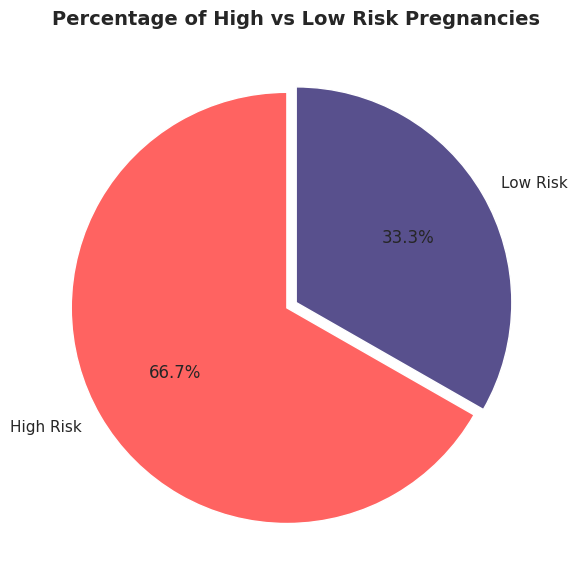

In [33]:
# Set general style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 7))
risk_counts = df['Risk_Level'].value_counts()
colors = ['#ff6361', '#58508d'] # Deep Coral and Dark Violet

plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, explode=(0.05, 0))
plt.title('Percentage of High vs Low Risk Pregnancies', fontsize=14, fontweight='bold')
plt.show()

## **Demographic Analysis (Age & Weight Histograms)**

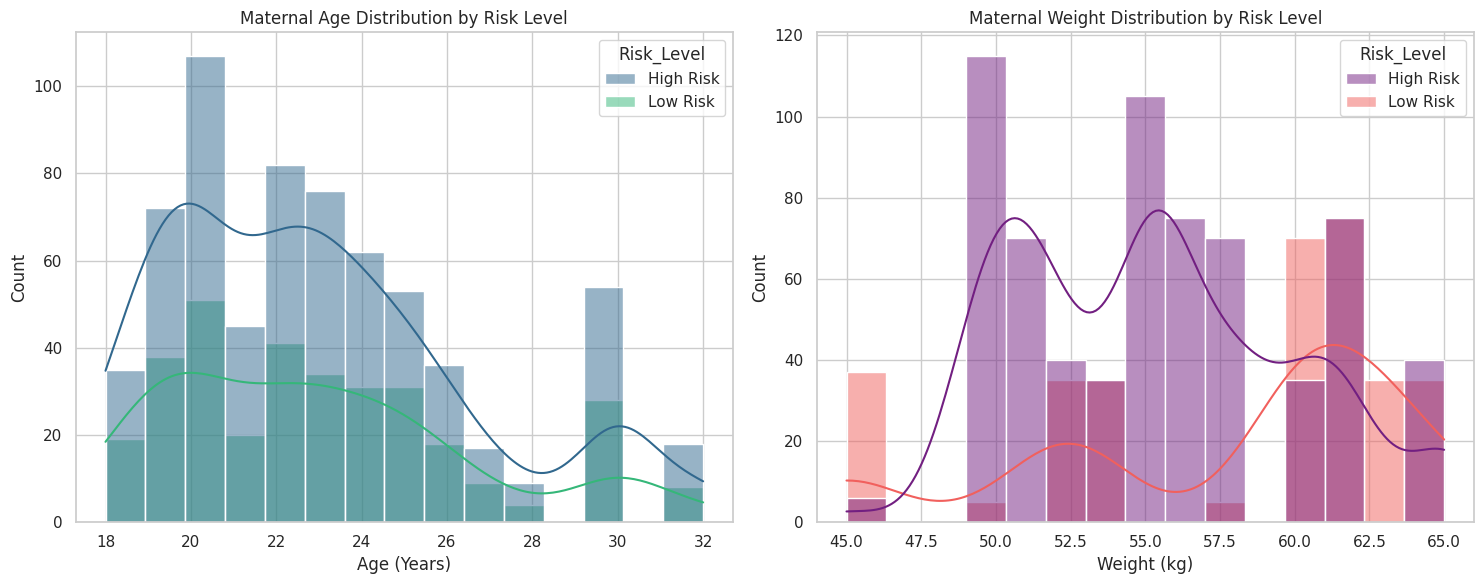

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Class-wise Age Distribution
sns.histplot(data=df, x='Age', hue='Risk_Level', kde=True, ax=ax[0], palette='viridis', bins=15)
ax[0].set_title('Maternal Age Distribution by Risk Level', fontsize=12)
ax[0].set_xlabel('Age (Years)')

# Class-wise Weight Distribution
sns.histplot(data=df, x='Weight', hue='Risk_Level', kde=True, ax=ax[1], palette='magma', bins=15)
ax[1].set_title('Maternal Weight Distribution by Risk Level', fontsize=12)
ax[1].set_xlabel('Weight (kg)')

plt.tight_layout()
plt.savefig('class_wise_maternal_distribution.png')

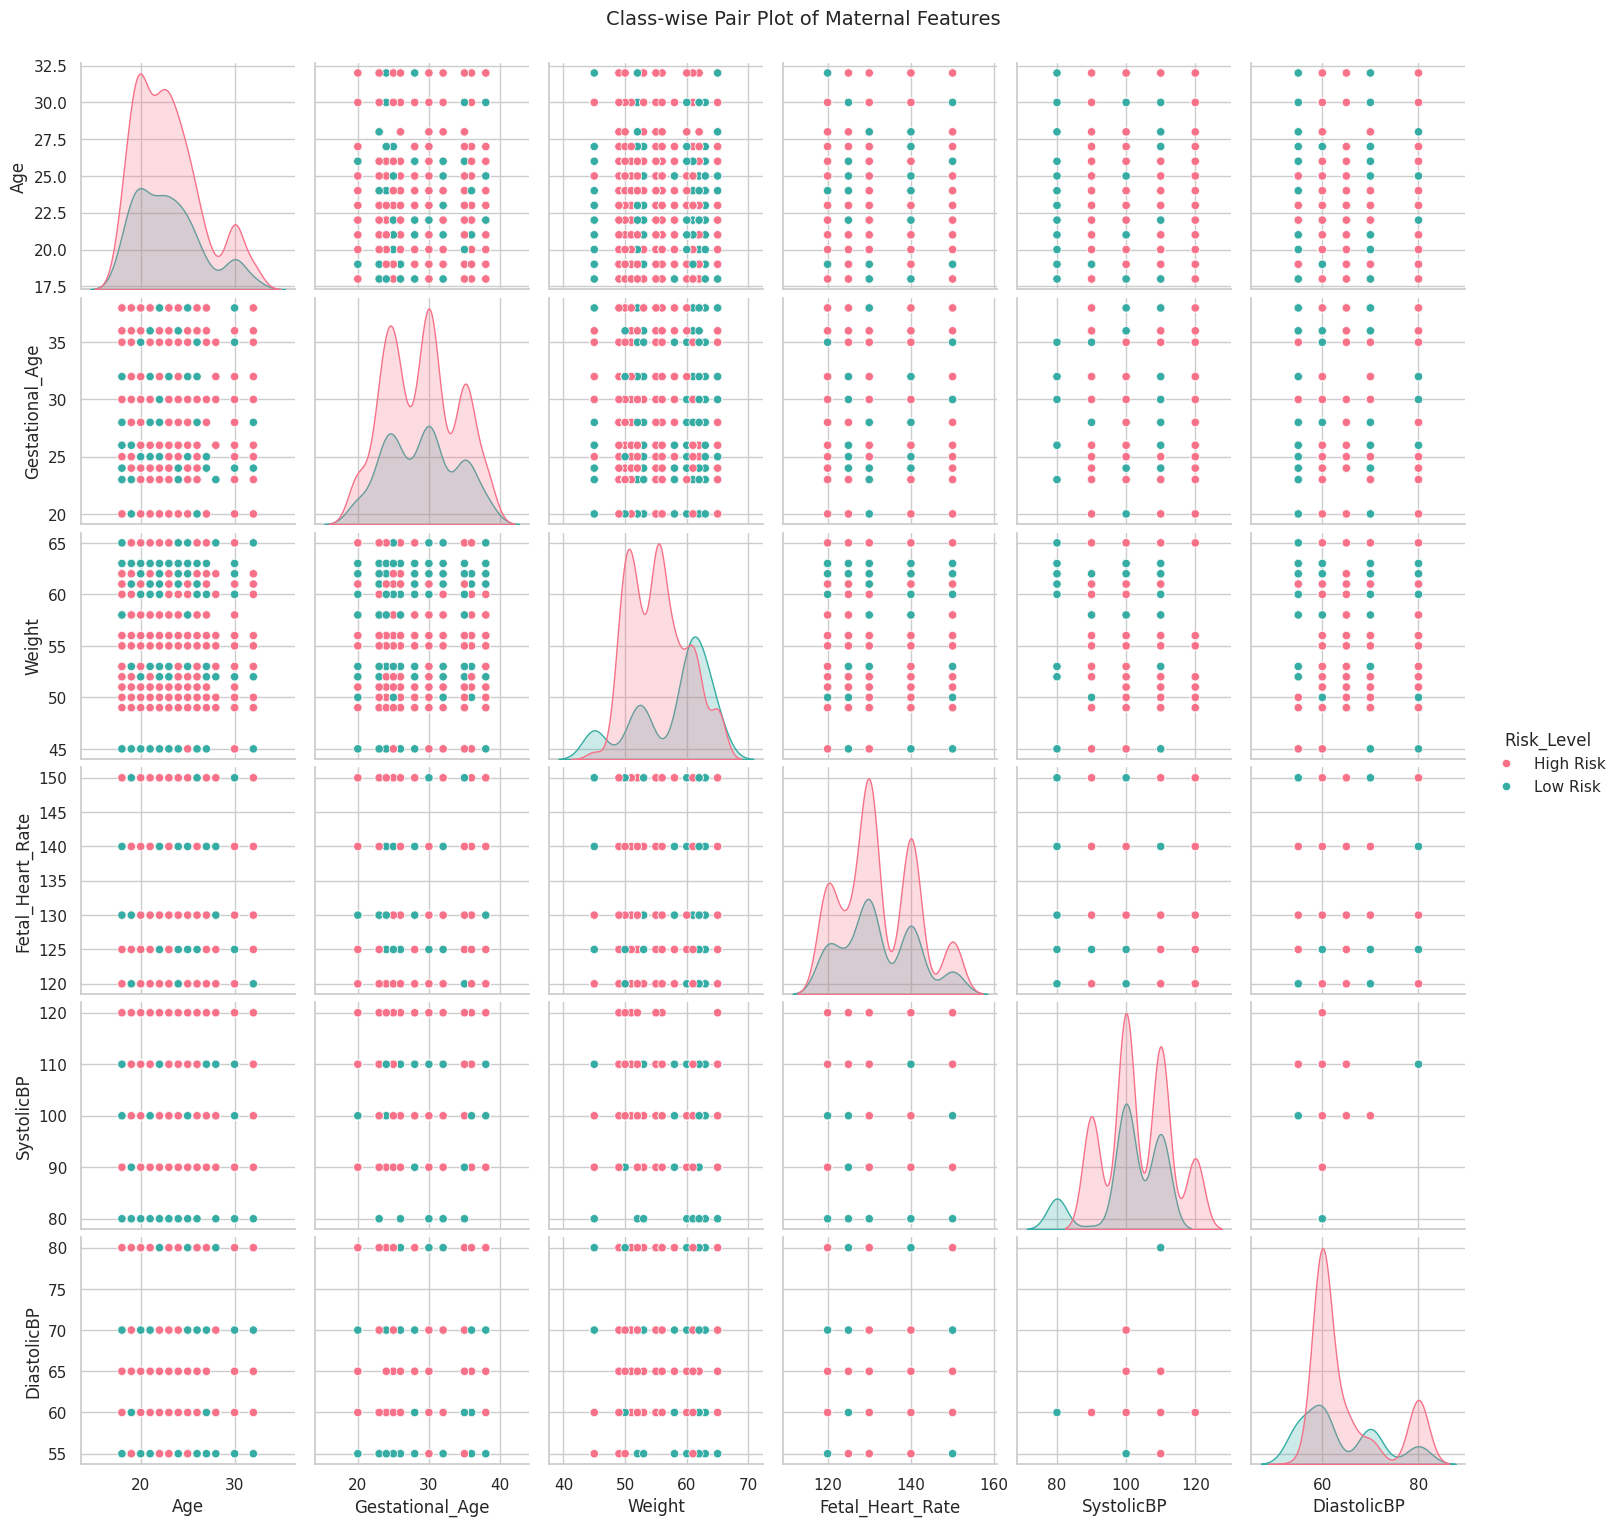

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the class-wise pair plot
# hue='RiskLevel' will separate the data points and KDEs by class
pair_plot = sns.pairplot(df, hue='Risk_Level', palette='husl', diag_kind='kde', height=2.5)

# Adding a title to the figure
pair_plot.fig.suptitle('Class-wise Pair Plot of Maternal Features', y=1.02, fontsize=14)

plt.savefig('class_wise_pair_plot.png')

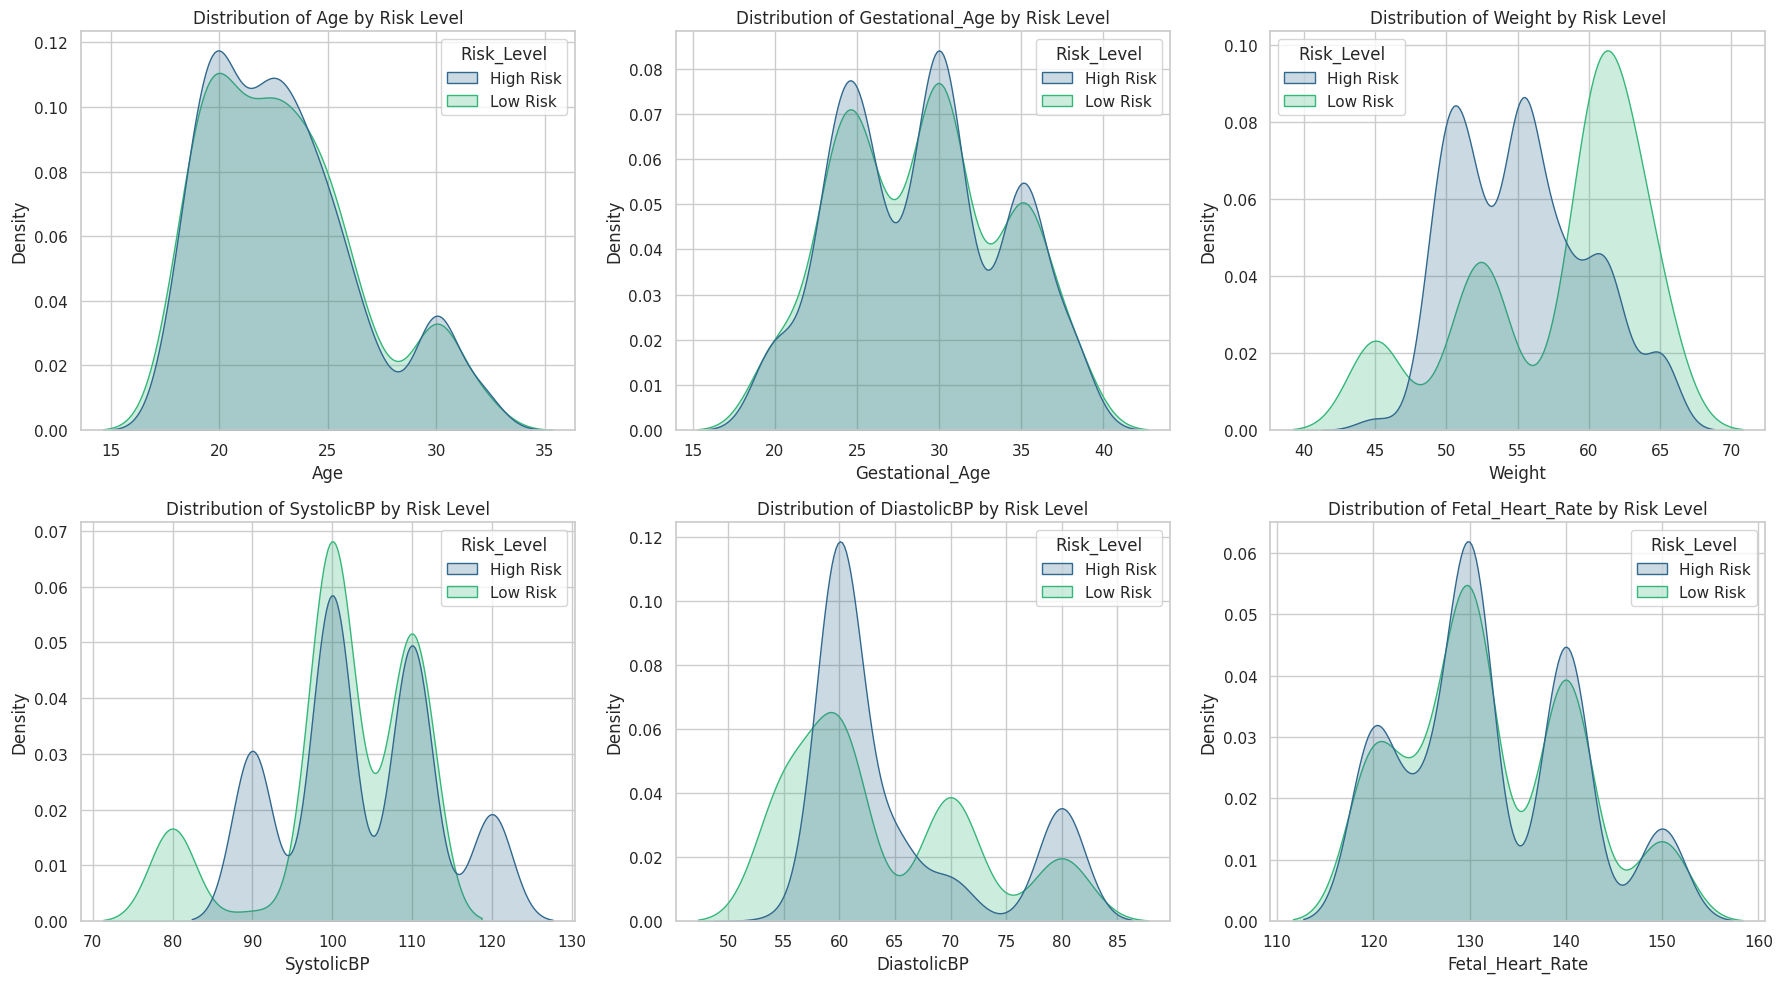

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Age', 'Gestational_Age', 'Weight', 'SystolicBP', 'DiastolicBP', 'Fetal_Heart_Rate']

# Calculate grid dimensions: 2 rows, 3 columns for 6 plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

for i, col in enumerate(numerical_cols):
    sns.kdeplot(data=df, x=col, hue='Risk_Level', fill=True, palette='viridis', common_norm=False, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Risk Level', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

## **Clinical Relationship (BP Scatter Plot)**

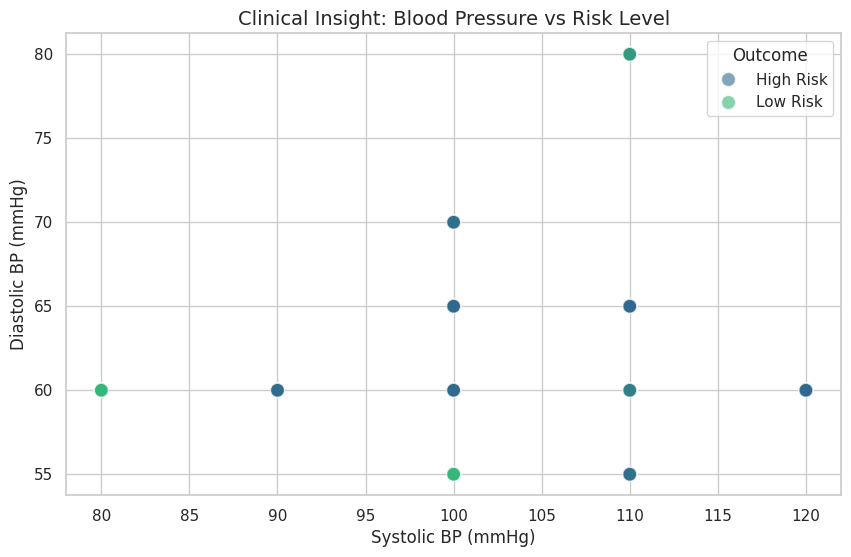

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='SystolicBP', y='DiastolicBP',
                hue='Risk_Level', palette='viridis', s=100, alpha=0.6)

plt.title('Clinical Insight: Blood Pressure vs Risk Level', fontsize=14)
plt.xlabel('Systolic BP (mmHg)')
plt.ylabel('Diastolic BP (mmHg)')
plt.legend(title='Outcome')
plt.show()

## **Categorical Influences (Urine Sugar & Gravida)**

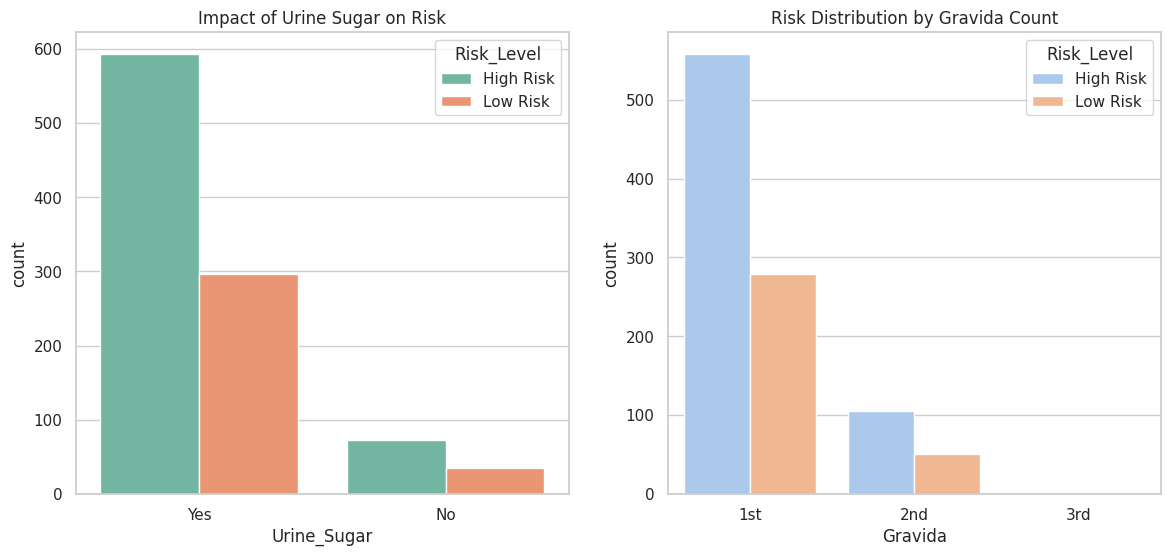

In [38]:
# Create a multi-plot figure
plt.figure(figsize=(14, 6))

# Urine Sugar count
plt.subplot(1, 2, 1)
sns.countplot(x='Urine_Sugar', hue='Risk_Level', data=df, palette='Set2')
plt.title('Impact of Urine Sugar on Risk', fontsize=12)

# Gravida (Number of Pregnancies) count
plt.subplot(1, 2, 2)
sns.countplot(x='Gravida', hue='Risk_Level', data=df, palette='pastel')
plt.title('Risk Distribution by Gravida Count', fontsize=12)

plt.show()

## **Feature Correlation Heatmap**

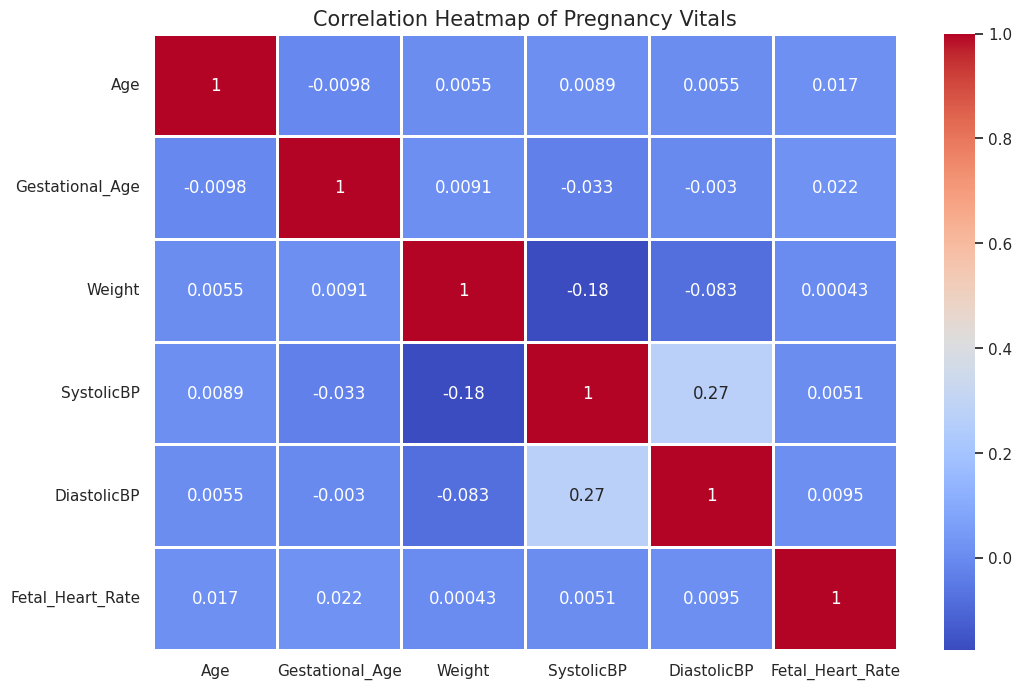

In [39]:
plt.figure(figsize=(12, 8))
numeric_cols = ['Age', 'Gestational_Age', 'Weight', 'SystolicBP', 'DiastolicBP', 'Fetal_Heart_Rate']
correlation = df[numeric_cols].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=1, linecolor='white')
plt.title('Correlation Heatmap of Pregnancy Vitals', fontsize=15)
plt.show()

## **Target Variable Distribution**

/tmp/ipykernel_558/844974619.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Level', data=df, palette=my_colors, ax=ax[0], edgecolor='black')


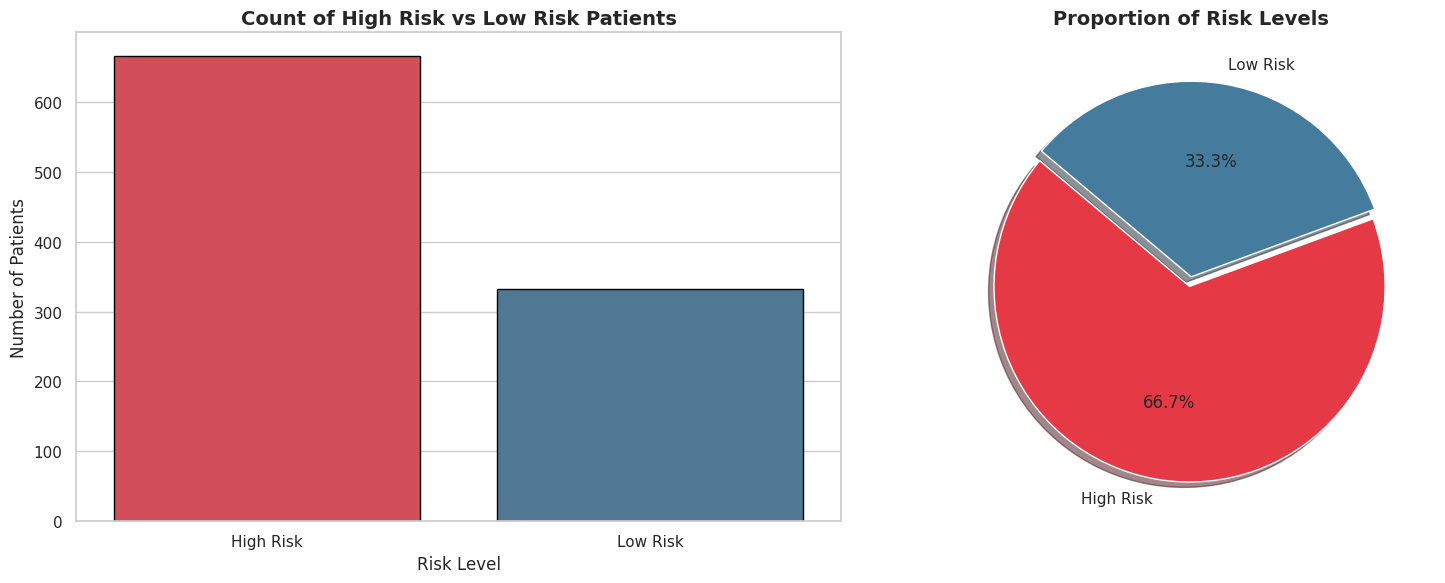

In [40]:
# Create a figure with two subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Define a custom color palette
# Red-ish for High Risk, Blue-ish for Low Risk
my_colors = ["#E63946", "#457B9D"]

# 1. Bar Chart for Counts
sns.countplot(x='Risk_Level', data=df, palette=my_colors, ax=ax[0], edgecolor='black')
ax[0].set_title('Count of High Risk vs Low Risk Patients', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Risk Level', fontsize=12)
ax[0].set_ylabel('Number of Patients', fontsize=12)

# 2. Pie Chart for Proportions
risk_data = df['Risk_Level'].value_counts()
ax[1].pie(risk_data,
        labels=risk_data.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=my_colors,
        explode=(0.05, 0), # Pull out the High Risk slice slightly
        shadow=True)
ax[1].set_title('Proportion of Risk Levels', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# **Feature Engineering and Data Splitting**
In this cell, the feature set (X) and target variable (y) are prepared. The categorical Risk_Level is converted into numeric values using label encoding. Features are standardized using StandardScaler to ensure that variables with different scales (like Blood Pressure vs. Age) contribute equally to the models. Finally, the data is partitioned into training and testing sets to evaluate performance on unseen data.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Select relevant numerical features for training
features = ['Age', 'Gestational_Age', 'Weight', 'SystolicBP', 'DiastolicBP', 'Fetal_Heart_Rate']
X = df[features]

# 2. Encode the target variable (High Risk = 1, Low Risk = 0)
le = LabelEncoder()
y = le.fit_transform(df['Risk_Level'])

# 3. Scale the features (Essential for SVM and Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 798
Testing set size: 200


# **Model Evaluation Function Definition**
This cell contains a reusable function designed to automate the evaluation process. It calculates execution time for both training and prediction phases. It computes core metrics: Accuracy, Precision, Recall, and F1-Score. Additionally, it generates a Classification Report and visualizes performance through a Confusion Matrix and an ROC (Receiver Operating Characteristic) Curve.

In [42]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    # Track Training Time
    start_train = time.time()
    model.fit(X_train, y_train)
    end_train = time.time()

    # Track Testing Time
    start_test = time.time()
    y_pred = model.predict(X_test)
    end_test = time.time()

    # Metrics Calculation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"--- {model_name} Performance ---")
    print(f"Training Time: {end_train - start_train:.4f}s")
    print(f"Testing Time: {end_test - start_test:.4f}s")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"\nClassification Report:\n", classification_report(y_test, y_pred))

    # Visualization
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='RdBu_r', ax=ax[0])
    ax[0].set_title(f'Confusion Matrix: {model_name}')
    ax[0].set_xlabel('Predicted Label')
    ax[0].set_ylabel('True Label')

    # ROC Curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    ax[1].plot(fpr, tpr, color='darkred', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_title(f'ROC Curve: {model_name}')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Train_Time": end_train - start_train,
        "Test_Time": end_test - start_test
    }

## **Training and Evaluation of Random Forest**
The Random Forest Classifier is trained in this cell. As an ensemble learning method, it constructs multiple decision trees and outputs the mode of the classes. This model is effective for capturing complex, non-linear relationships within the medical vitals.

--- Random Forest Performance ---
Training Time: 0.2238s
Testing Time: 0.0098s
Accuracy: 0.8750

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91       138
           1       0.88      0.69      0.77        62

    accuracy                           0.88       200
   macro avg       0.88      0.83      0.84       200
weighted avg       0.88      0.88      0.87       200



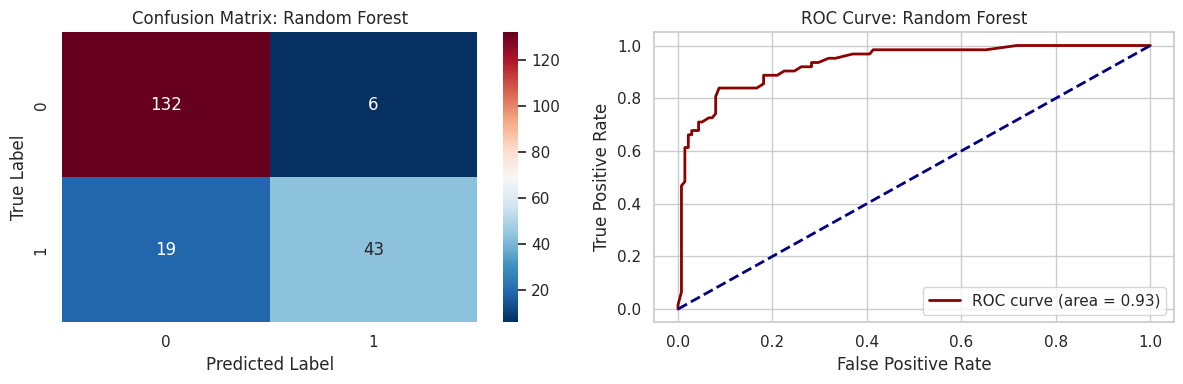

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_results = evaluate_model(rf_model, "Random Forest", X_train, X_test, y_train, y_test)

## **Training and Evaluation of LightGBM**
This cell trains the LightGBM (Light Gradient Boosting Machine) model. LightGBM is a high-performance framework that uses a leaf-wise tree growth strategy rather than a level-wise one. This allows it to achieve faster training speeds and lower memory consumption, making it particularly powerful for large datasets or when high-dimensional feature sets are involved.

--- Gradient Boosting Performance ---
Training Time: 0.1682s
Testing Time: 0.0010s
Accuracy: 0.8950

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.93       138
           1       0.90      0.74      0.81        62

    accuracy                           0.90       200
   macro avg       0.90      0.85      0.87       200
weighted avg       0.90      0.90      0.89       200



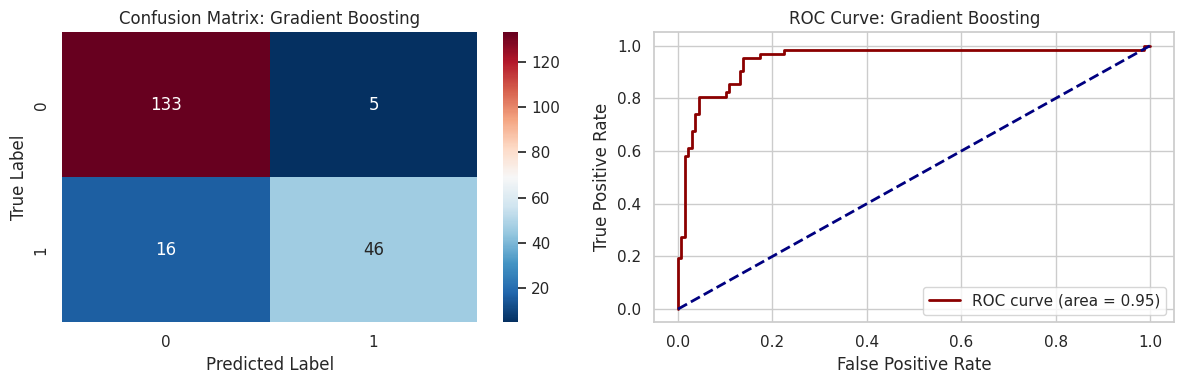

In [44]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Evaluate using your function
gb_results = evaluate_model(gb_model, "Gradient Boosting", X_train, X_test, y_train, y_test)

## **Training and Evaluation of Gradient Boosting**
The Gradient Boosting Classifier is implemented here. Unlike Random Forest, which builds trees independently, Gradient Boosting builds trees sequentially, where each new tree aims to minimize the errors (residuals) of the previous ones. This additive approach is highly effective at reducing bias and often yields superior predictive accuracy on structured tabular data.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- LightGBM Performance ---
Training Time: 0.0403s
Testing Time: 0.0041s
Accuracy: 0.8800

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91       138
           1       0.83      0.77      0.80        62

    accuracy                           0.88       200
   macro avg       0.86      0.85      0.86       200
weighted avg       0.88      0.88      0.88       200



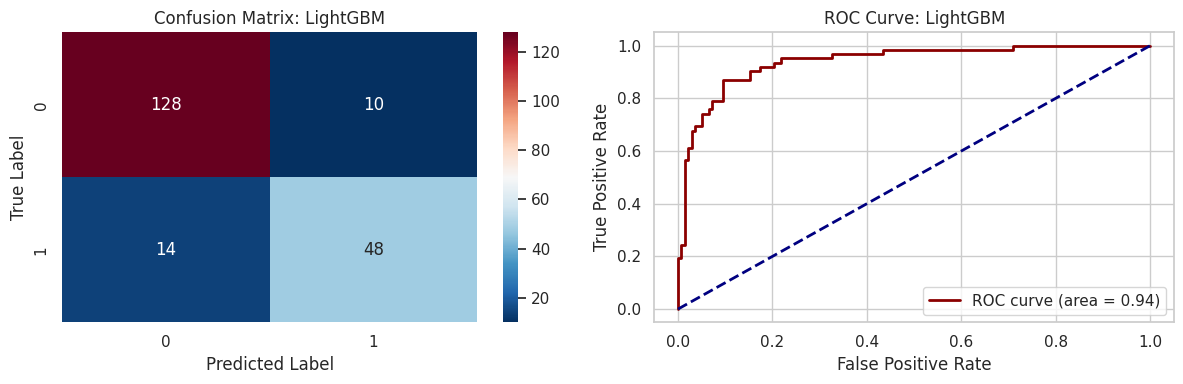

In [45]:
from lightgbm import LGBMClassifier

# Initialize the model
# 'verbosity=-1' keeps the output clean by hiding non-critical warnings
lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=-1)

# Evaluate using your function
lgbm_results = evaluate_model(lgbm_model, "LightGBM", X_train, X_test, y_train, y_test)

##**Comparative Performance Summary**
In the final cell, the metrics from all three models are consolidated into a single DataFrame. This allows for a direct side-by-side comparison of accuracy, precision, and processing speeds to determine the most effective model for the dataset.

In [46]:
# Aggregate results
comparison_df = pd.DataFrame([rf_results, gb_results, lgbm_results])

# Display summary table
print("### Model Performance Comparison ###")
comparison_df.sort_values(by='Accuracy', ascending=False)

### Model Performance Comparison ###


,Model,Accuracy,Precision,Recall,F1,Train_Time,Test_Time
1,Gradient Boosting,0.895,0.901961,0.741935,0.814159,0.168191,0.000994
2,LightGBM,0.880,0.827586,0.774194,0.800000,0.040313,0.004085
0,Random Forest,0.875,0.877551,0.693548,0.774775,0.223777,0.009802


## **Hyperparameter Tuning for Random Forest**
In this we perform hyperparameter tuning using GridSearch

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
--- Tuned Random Forest Performance ---
Training Time: 0.1893s
Testing Time: 0.0094s
Accuracy: 0.8750

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91       138
           1       0.86      0.71      0.78        62

    accuracy                           0.88       200
   macro avg       0.87      0.83      0.85       200
weighted avg       0.87      0.88      0.87       200



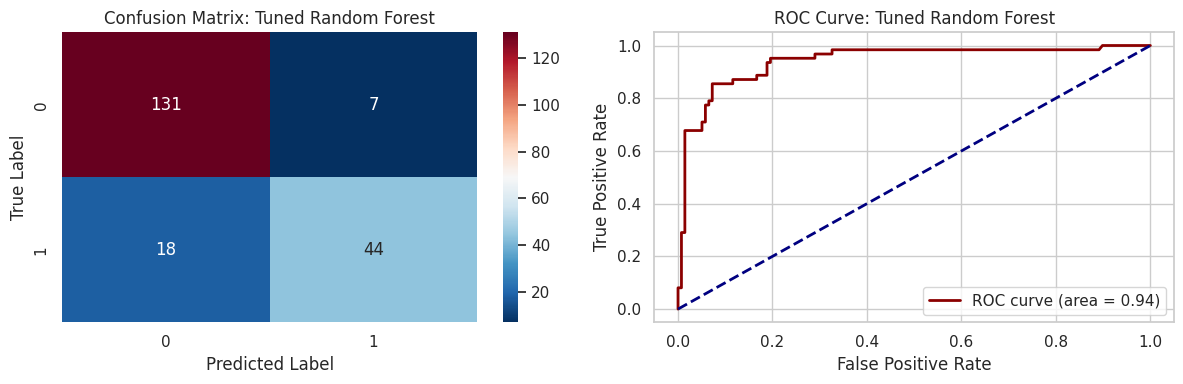

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
# We focus on the most impactful hyperparameters for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# 2. Initialize the base model
rf_base = RandomForestClassifier(random_state=42)

# 3. Set up the Grid Search
# Using 5-fold cross-validation
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1 # Added verbose to see progress
)

# 4. Fit the grid search
grid_search_rf.fit(X_train, y_train)

# 5. Extract the best model and evaluate
best_rf_model = grid_search_rf.best_estimator_

print(f"Best Parameters: {grid_search_rf.best_params_}")

# Using your original evaluation function
rf_results_tuned = evaluate_model(best_rf_model, "Tuned Random Forest", X_train, X_test, y_train, y_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best LightGBM Parameters: {'importance_type': 'gain', 'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}
--- Tuned LightGBM Performance ---
Training Time: 0.1165s
Testing Time: 0.0068s
Accuracy: 0.8850

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92       138
           1       0.84      0.77      0.81        62

    accuracy                           0.89       200
   macro avg       0.87      0.85      0.86       200
weighted avg       0.88      0.89      0.88       200



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


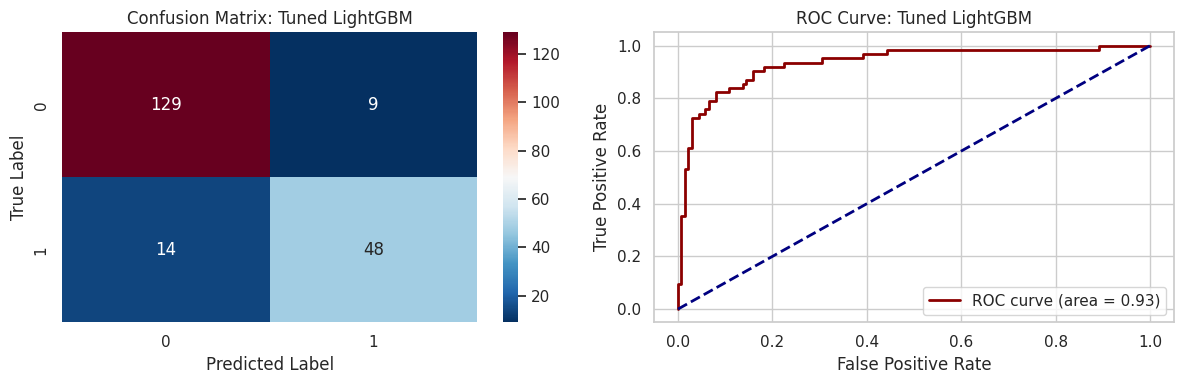

In [22]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
# We focus on the leaf-wise growth and learning speed
param_grid_lgbm = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'min_child_samples': [20, 30],
    'importance_type': ['gain']
}

# 2. Initialize the base model
lgbm_base = LGBMClassifier(random_state=42, verbosity=-1)

# 3. Set up the Grid Search
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid_lgbm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. Fit the grid search
grid_search_lgbm.fit(X_train, y_train)

# 5. Extract the best model and evaluate
best_lgbm_model = grid_search_lgbm.best_estimator_

print(f"Best LightGBM Parameters: {grid_search_lgbm.best_params_}")

# Using your original evaluation function
lgbm_results_tuned = evaluate_model(best_lgbm_model, "Tuned LightGBM", X_train, X_test, y_train, y_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Gradient Boosting Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
--- Tuned Gradient Boosting Performance ---
Training Time: 0.6159s
Testing Time: 0.0020s
Accuracy: 0.8700

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91       138
           1       0.85      0.71      0.77        62

    accuracy                           0.87       200
   macro avg       0.86      0.83      0.84       200
weighted avg       0.87      0.87      0.87       200



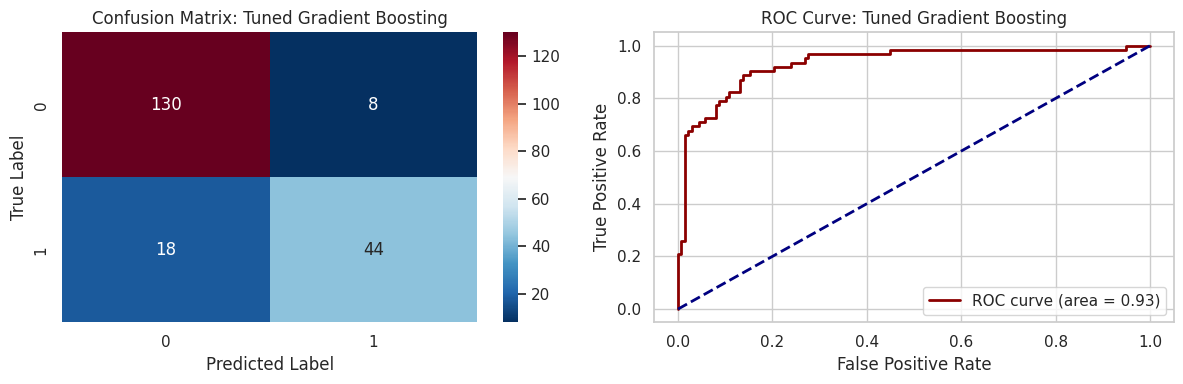

In [23]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
# Boosting requires a careful balance between step size and number of trees
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0] # Helps prevent overfitting by using a fraction of samples
}

# 2. Initialize the base model
gb_base = GradientBoostingClassifier(random_state=42)

# 3. Set up the Grid Search
grid_search_gb = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. Fit the grid search
grid_search_gb.fit(X_train, y_train)

# 5. Extract the best model and evaluate
best_gb_model = grid_search_gb.best_estimator_

print(f"Best Gradient Boosting Parameters: {grid_search_gb.best_params_}")

# Using your original evaluation function
gb_results_tuned = evaluate_model(best_gb_model, "Tuned Gradient Boosting", X_train, X_test, y_train, y_test)

In [24]:
# Aggregate results
tuned_df = pd.DataFrame([rf_results_tuned, gb_results_tuned, lgbm_results_tuned])

# Display summary table
print("### Model Performance Comparison ###")
tuned_df.sort_values(by='Accuracy', ascending=False)

### Model Performance Comparison ###


,Model,Accuracy,Precision,Recall,F1,Train_Time,Test_Time
2,Tuned LightGBM,0.885,0.842105,0.774194,0.806723,0.116543,0.006816
0,Tuned Random Forest,0.875,0.862745,0.709677,0.778761,0.189336,0.009351
1,Tuned Gradient Boosting,0.870,0.846154,0.709677,0.771930,0.615946,0.002042


## **Model Validation using K-Fold Cross-Validation**
To ensure the reliability of our results and guard against **overfitting**, we implement K-Fold Cross-Validation.
Instead of a single train-test split, the dataset is divided into $k$ subsets (folds). The model is trained on $k-1$ folds and validated on the remaining fold. This process repeats $k$ times, ensuring every data point is used for both training and validation.

We use the **Mean Accuracy** and **Standard Deviation** across folds to assess the stability of the Logistic Regression, Random Forest, and SVM models.

In [25]:
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

# Define the models (using your tuned versions if available)
models = [
    ("Gradient Boosting", best_gb_model),
    ("Random Forest", best_rf_model),
    ("LightGBM", best_lgbm_model)
]

# Define the metrics we want to track
scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

print("### K-Fold Cross-Validation Results (K=5) ###\n")

cv_results = []

for name, model in models:
    # cross_validate returns a dict with fit_times, score_times, and test_scores
    results = cross_validate(model, X_train, y_train, cv=5, scoring=scoring_metrics)

    # Calculate means and standard deviations
    res_entry = {
        "Model": name,
        "Accuracy": results['test_accuracy'].mean(),
        "Precision": results['test_precision_weighted'].mean(),
        "Recall": results['test_recall_weighted'].mean(),
        "F1-Score": results['test_f1_weighted'].mean(),
        "Std_Dev (Acc)": results['test_accuracy'].std()
    }

    cv_results.append(res_entry)

    print(f"{name}:")
    print(f"  F1-Score: {res_entry['F1-Score']:.4f}")
    print(f"  Accuracy: {res_entry['Accuracy']:.4f} (±{res_entry['Std_Dev (Acc)']:.4f})\n")

# Create a clean comparison table
cv_df = pd.DataFrame(cv_results).set_index("Model")
print(cv_df)

### K-Fold Cross-Validation Results (K=5) ###

Gradient Boosting:
  F1-Score: 0.9012
  Accuracy: 0.9022 (±0.0281)

Random Forest:
  F1-Score: 0.8788
  Accuracy: 0.8809 (±0.0222)



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM:
  F1-Score: 0.8977
  Accuracy: 0.8985 (±0.0280)

                   Accuracy  Precision    Recall  F1-Score  Std_Dev (Acc)
Model                                                                    
Gradient Boosting  0.902217   0.902575  0.902217  0.901211       0.028120
Random Forest      0.880943   0.881128  0.880943  0.878792       0.022190
LightGBM           0.898459   0.899434  0.898459  0.897694       0.028006


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# **Explainable AI (XAI) for Hillas Parameter Analysis**

To understand the decision-making process of our classifier, we employ **SHAP (SHapley Additive exPlanations)**. In the context of Gamma-Hadron separation, XAI helps us validate that the model is learning physical characteristics of particle showers rather than noise artifacts.

### **Key Interpretations:**
* **Width (Transverse Spread):** SHAP values often indicate that narrower showers (smaller Width) are the strongest indicators of Gamma-ray signals.
* **Length (Longitudinal Spread):** XAI reveals how the model uses Length to distinguish the depth of atmospheric penetration.
* **Dist (Distance from Center):** This parameter often shows a non-linear relationship in XAI plots, as showers too close to the camera edge are less reliable.

By using SHAP, we transform a "Black Box" ensemble model into a transparent tool where each classification can be traced back to specific physical measurements of the Cherenkov light pool.

### SHAP Feature Importance (for 'High Risk' class) ###


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


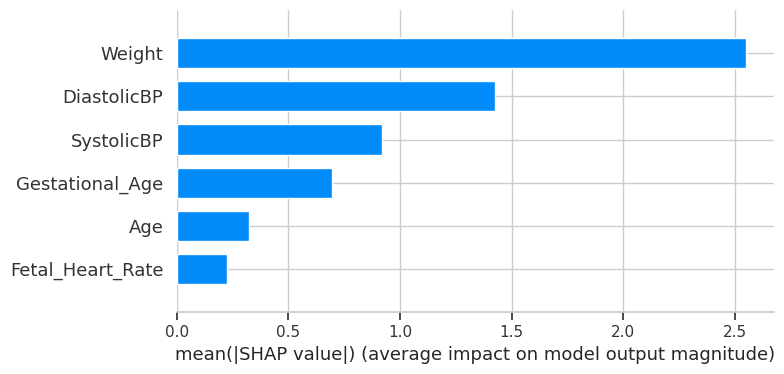

In [26]:
import shap

# Initialize the SHAP explainer (works best with tree-based models like Random Forest)
explainer = shap.TreeExplainer(best_lgbm_model)
# For binary classification with LightGBM, shap.TreeExplainer typically returns
# SHAP values as a 2D array (num_samples, num_features) for the positive class.
shap_values = explainer.shap_values(X_test)

# Plotting Global Importance for the 'High Risk' class (assuming it's class 1)
print("### SHAP Feature Importance (for 'High Risk' class) ###")
# The IndexError indicates shap_values is a 2D array, not 3D.
# So, remove the third dimension indexing `[:, :, 1]`.
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=X.columns)

# Plotting a single prediction's explanation for the 'High Risk' class
# (Visualizes how features push the result from the base value)
shap.initjs()
# For binary classification, explainer.expected_value is usually a scalar base value.
# shap_values[0, :] selects the SHAP values for the first sample across all features.
shap.force_plot(explainer.expected_value, shap_values[0, :], X_test[0,:], feature_names=X.columns)